# 02 — Descriptive comparison of haematological and inflammatory biomarkers between iron-supplemented and non-supplemented Brazilian infants (6–24 months)

**Purpose:** unadjusted exploratory comparison of biomarker distributions by iron supplementation status. This notebook is descriptive only — no causal claims, no prediction, no inference about effect sizes for the manuscript. Final inference comes later from outer-bootstrap regression and Causal Forest analyses.

**Sample:** Brazilian infants aged 6–24 months from ENANI-2019.

**Exposure:** any iron-containing supplement use in the preceding six months (`vd_supl1_com_ferro`).

**Biomarker outcomes** (uniformly measured under the survey blood-collection protocol):
- Continuous: haemoglobin, ferritin, haematocrit, MCV, MCH, MCHC, RDW, C-reactive protein.
- Binary derived: anaemia (Hb < 10.5 g/dL), iron deficiency (ferritin < 12 ng/mL), elevated CRP (> 5 mg/L). **Children with missing biomarker measurement are excluded from the binary outcome (NaN preserved); they are not classified as zero.**

**Inference reported in every table:**
- Continuous: mean and 95% CI per group; difference of means with Welch CI; Welch t-test and Mann–Whitney U p-values.
- Binary: prevalence and 95% Wilson CI per group; risk difference with Newcombe hybrid-score CI; chi-square (or Fisher's exact when cell counts are sparse).

All thresholds are descriptive significance markers (p < 0.05) without multiple-testing correction at this stage; no claim of causal association is made from this notebook.

In [1]:
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_rows', 200)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

DATA_PATH = Path('../Data/data_crianca_calib_anon.csv')
assert DATA_PATH.exists(), f'Data file not found at {DATA_PATH.resolve()}'
print(f'Data path: {DATA_PATH.resolve()}')

Data path: /Users/marcelocarvalhoesilva/project/IronBrazil/Data/data_crianca_calib_anon.csv


## Helper functions: confidence intervals

- `wilson_ci`: Wilson score interval for a single binomial proportion (better small-sample behaviour than the normal approximation).
- `newcombe_diff_ci`: Newcombe hybrid-score interval for the difference of two independent proportions.
- `mean_ci`: standard normal CI around a sample mean (sample sizes are large enough that t- and z-intervals are interchangeable).
- `welch_diff_ci`: Welch CI for the difference of two means with unequal variances.

In [2]:
Z95 = 1.959964

def wilson_ci(events, n):
    if n == 0:
        return (np.nan, np.nan, np.nan)
    p = events / n
    z = Z95
    denom = 1 + z * z / n
    centre = (p + z * z / (2 * n)) / denom
    half_width = z * np.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / denom
    return p, max(0.0, centre - half_width), min(1.0, centre + half_width)

def newcombe_diff_ci(events0, n0, events1, n1):
    p0, lo0, hi0 = wilson_ci(events0, n0)
    p1, lo1, hi1 = wilson_ci(events1, n1)
    diff = p1 - p0
    L = diff - np.sqrt((p1 - lo1) ** 2 + (hi0 - p0) ** 2)
    U = diff + np.sqrt((hi1 - p1) ** 2 + (p0 - lo0) ** 2)
    return diff, L, U

def mean_ci(values):
    n = len(values)
    if n < 2:
        return (np.nan, np.nan, np.nan)
    m = values.mean()
    se = values.std(ddof=1) / np.sqrt(n)
    return m, m - Z95 * se, m + Z95 * se

def welch_diff_ci(g0, g1):
    n0, n1 = len(g0), len(g1)
    if n0 < 2 or n1 < 2:
        return (np.nan, np.nan, np.nan)
    diff = g1.mean() - g0.mean()
    se = np.sqrt(g0.var(ddof=1) / n0 + g1.var(ddof=1) / n1)
    return diff, diff - Z95 * se, diff + Z95 * se

def to_binary_with_nan(series, threshold, comparator='lt'):
    if comparator == 'lt':
        cond = series < threshold
    elif comparator == 'gt':
        cond = series > threshold
    else:
        raise ValueError(comparator)
    return cond.where(series.notna(), other=pd.NA).astype('Int64')

## 1. Load and filter the analytic sample

In [3]:
raw = pd.read_csv(DATA_PATH, low_memory=False)
print(f'Total rows in ENANI-2019 child file: {len(raw):,}')

raw['age_months'] = raw['b05a_idade_em_meses'].astype(str).str.extract(r'(\d+)').astype(float)
df = raw[(raw['age_months'] >= 6) & (raw['age_months'] <= 24)].copy()
print(f'Infants aged 6–24 months: {len(df):,}')

df['iron_any'] = (df['vd_supl1_com_ferro'] == 'Sim').astype(int)
exposure_counts = df['iron_any'].value_counts().rename({0: 'Unexposed', 1: 'Exposed'})
exposure_counts.index.name = 'Iron supplementation (preceding 6 mo)'
print(exposure_counts)
print(f'\nExposure prevalence: {df["iron_any"].mean() * 100:.1f}%')

Total rows in ENANI-2019 child file: 14,558
Infants aged 6–24 months: 4,601
Iron supplementation (preceding 6 mo)
Unexposed    3248
Exposed      1353
Name: count, dtype: int64

Exposure prevalence: 29.4%


## 2. Define biomarker variables

Binary biomarkers preserve missingness: children without the underlying laboratory measurement are NaN, not 0.

In [4]:
df['hb'] = pd.to_numeric(df['vd_hb_final'], errors='coerce')
df['ferritin'] = pd.to_numeric(df['vd_ferri_final'], errors='coerce')
df['haematocrit'] = pd.to_numeric(df['vd_ht_final'], errors='coerce')
df['mcv'] = pd.to_numeric(df['vd_vcm_final'], errors='coerce')
df['mch'] = pd.to_numeric(df['vd_hcm_final'], errors='coerce')
df['mchc'] = pd.to_numeric(df['vd_chcm_final'], errors='coerce')
df['rdw'] = pd.to_numeric(df['vd_rdw_final'], errors='coerce')
df['crp'] = pd.to_numeric(df['vd_pcr_final'], errors='coerce')

df['anaemia'] = to_binary_with_nan(df['hb'], 10.5, 'lt')
df['iron_deficiency'] = to_binary_with_nan(df['ferritin'], 12, 'lt')
df['crp_elevated'] = to_binary_with_nan(df['crp'], 5, 'gt')

continuous_biomarkers = {
    'hb': 'Haemoglobin (g/dL)',
    'ferritin': 'Ferritin (ng/mL)',
    'haematocrit': 'Haematocrit (%)',
    'mcv': 'MCV (fL)',
    'mch': 'MCH (pg)',
    'mchc': 'MCHC (g/dL)',
    'rdw': 'RDW (%)',
    'crp': 'C-reactive protein (mg/L)',
}
binary_biomarkers = {
    'anaemia': 'Anaemia (Hb < 10.5 g/dL)',
    'iron_deficiency': 'Iron deficiency (ferritin < 12 ng/mL)',
    'crp_elevated': 'Elevated CRP (> 5 mg/L)',
}

availability_rows = []
for var, label in {**continuous_biomarkers, **binary_biomarkers}.items():
    s = df[var]
    availability_rows.append({
        'Biomarker': label,
        'N (total)': int(s.notna().sum()),
        'N (unexposed)': int(((df['iron_any'] == 0) & s.notna()).sum()),
        'N (exposed)': int(((df['iron_any'] == 1) & s.notna()).sum()),
    })
availability = pd.DataFrame(availability_rows).set_index('Biomarker')
availability

,N (total),N (unexposed),N (exposed)
Biomarker,,,
Haemoglobin (g/dL),2788,1983,805
Ferritin (ng/mL),2728,1929,799
Haematocrit (%),2788,1983,805
MCV (fL),2788,1983,805
MCH (pg),2788,1983,805
MCHC (g/dL),2788,1983,805
RDW (%),2785,1982,803
C-reactive protein (mg/L),2756,1964,792
Anaemia (Hb < 10.5 g/dL),2788,1983,805


## 3. Continuous biomarkers — group descriptives and unadjusted differences with 95% CIs

In [5]:
def summarise_continuous(df, var, exposure='iron_any'):
    sub = df[[var, exposure]].dropna()
    g0 = sub.loc[sub[exposure] == 0, var]
    g1 = sub.loc[sub[exposure] == 1, var]
    if len(g0) < 5 or len(g1) < 5:
        return None
    m0, m0_lo, m0_hi = mean_ci(g0)
    m1, m1_lo, m1_hi = mean_ci(g1)
    diff, diff_lo, diff_hi = welch_diff_ci(g0, g1)
    welch = stats.ttest_ind(g0, g1, equal_var=False)
    mw = stats.mannwhitneyu(g0, g1, alternative='two-sided')
    return {
        'n_unexposed': len(g0),
        'n_exposed': len(g1),
        'mean_unexposed': m0,
        'mean_unexposed_lo': m0_lo,
        'mean_unexposed_hi': m0_hi,
        'sd_unexposed': g0.std(ddof=1),
        'mean_exposed': m1,
        'mean_exposed_lo': m1_lo,
        'mean_exposed_hi': m1_hi,
        'sd_exposed': g1.std(ddof=1),
        'median_unexposed': g0.median(),
        'iqr_low_unexposed': g0.quantile(0.25),
        'iqr_high_unexposed': g0.quantile(0.75),
        'median_exposed': g1.median(),
        'iqr_low_exposed': g1.quantile(0.25),
        'iqr_high_exposed': g1.quantile(0.75),
        'mean_difference': diff,
        'mean_difference_lo': diff_lo,
        'mean_difference_hi': diff_hi,
        'p_welch': float(welch.pvalue),
        'p_mannwhitney': float(mw.pvalue),
    }

rows = []
for var, label in continuous_biomarkers.items():
    r = summarise_continuous(df, var)
    if r is None:
        continue
    rows.append({'Biomarker': label, **r})
continuous_table = pd.DataFrame(rows).set_index('Biomarker')
continuous_table

,n_unexposed,n_exposed,mean_unexposed,mean_unexposed_lo,mean_unexposed_hi,sd_unexposed,mean_exposed,mean_exposed_lo,mean_exposed_hi,sd_exposed,...,iqr_low_unexposed,iqr_high_unexposed,median_exposed,iqr_low_exposed,iqr_high_exposed,mean_difference,mean_difference_lo,mean_difference_hi,p_welch,p_mannwhitney
Biomarker,,,,,,,,,,,,,,,,,,,,,
Haemoglobin (g/dL),1983,805,11.7222,11.6667,11.7776,1.2596,11.9201,11.8317,12.0085,1.2793,...,11.0000,12.5000,11.9000,11.2000,12.6000,0.1979,0.0936,0.3023,0.0002,0.0003
Ferritin (ng/mL),1929,799,23.7847,22.7588,24.8106,22.9900,27.7464,25.6485,29.8443,30.2557,...,11.2000,28.9000,21.1000,13.1500,32.2500,3.9617,1.6264,6.2970,0.0009,0.0000
Haematocrit (%),1983,805,35.2888,35.1325,35.4450,3.5491,35.7425,35.4858,35.9991,3.7152,...,33.2000,37.3000,35.6000,33.6000,37.5000,0.4537,0.1533,0.7542,0.0031,0.0097
MCV (fL),1983,805,74.6982,74.3813,75.0151,7.2004,75.7212,75.2913,76.1512,6.2238,...,71.2000,78.8000,76.2000,72.5000,79.6000,1.0230,0.4889,1.5571,0.0002,0.0001
MCH (pg),1983,805,25.1407,24.9611,25.3203,4.0816,25.3619,25.1483,25.5754,3.0917,...,23.5000,26.7000,25.6000,24.1000,26.8000,0.2212,-0.0579,0.5002,0.1205,0.0003
MCHC (g/dL),1983,805,33.2455,33.1696,33.3214,1.7240,33.3507,33.2518,33.4496,1.4314,...,32.5000,34.1000,33.4000,32.6000,34.2000,0.1052,-0.0194,0.2298,0.0983,0.0504
RDW (%),1982,803,15.0837,14.9893,15.1781,2.1434,14.8465,14.7039,14.9890,2.0613,...,13.8000,16.1000,14.5000,13.6000,15.8500,-0.2373,-0.4082,-0.0663,0.0066,0.0026
C-reactive protein (mg/L),1964,792,3.4441,3.0208,3.8674,9.5716,3.3572,2.6232,4.0913,10.5394,...,0.2400,2.3700,0.4750,0.2000,1.8300,-0.0869,-0.9342,0.7605,0.8408,0.0003


In [6]:
def fmt_mean_ci(row, group):
    return f"{row[f'mean_{group}']:.2f} [{row[f'mean_{group}_lo']:.2f}, {row[f'mean_{group}_hi']:.2f}]"

def fmt_diff_ci(row):
    return f"{row['mean_difference']:+.3f} [{row['mean_difference_lo']:+.3f}, {row['mean_difference_hi']:+.3f}]"

def fmt_median_iqr(row, group):
    return f"{row[f'median_{group}']:.2f} [{row[f'iqr_low_{group}']:.2f}, {row[f'iqr_high_{group}']:.2f}]"

continuous_compact = pd.DataFrame({
    'N (total)': continuous_table['n_unexposed'] + continuous_table['n_exposed'],
    'Unexposed mean [95% CI]': [fmt_mean_ci(r, 'unexposed') for _, r in continuous_table.iterrows()],
    'Exposed mean [95% CI]': [fmt_mean_ci(r, 'exposed') for _, r in continuous_table.iterrows()],
    'Mean diff [95% CI]': [fmt_diff_ci(r) for _, r in continuous_table.iterrows()],
    'Welch p': [f"{r['p_welch']:.4f}" for _, r in continuous_table.iterrows()],
    'Mann–Whitney p': [f"{r['p_mannwhitney']:.4f}" for _, r in continuous_table.iterrows()],
})
continuous_compact

,N (total),Unexposed mean [95% CI],Exposed mean [95% CI],Mean diff [95% CI],Welch p,Mann–Whitney p
Biomarker,,,,,,
Haemoglobin (g/dL),2788,"11.72 [11.67, 11.78]","11.92 [11.83, 12.01]","+0.198 [+0.094, +0.302]",0.0002,0.0003
Ferritin (ng/mL),2728,"23.78 [22.76, 24.81]","27.75 [25.65, 29.84]","+3.962 [+1.626, +6.297]",0.0009,0.0000
Haematocrit (%),2788,"35.29 [35.13, 35.44]","35.74 [35.49, 36.00]","+0.454 [+0.153, +0.754]",0.0031,0.0097
MCV (fL),2788,"74.70 [74.38, 75.02]","75.72 [75.29, 76.15]","+1.023 [+0.489, +1.557]",0.0002,0.0001
MCH (pg),2788,"25.14 [24.96, 25.32]","25.36 [25.15, 25.58]","+0.221 [-0.058, +0.500]",0.1205,0.0003
MCHC (g/dL),2788,"33.25 [33.17, 33.32]","33.35 [33.25, 33.45]","+0.105 [-0.019, +0.230]",0.0983,0.0504
RDW (%),2785,"15.08 [14.99, 15.18]","14.85 [14.70, 14.99]","-0.237 [-0.408, -0.066]",0.0066,0.0026
C-reactive protein (mg/L),2756,"3.44 [3.02, 3.87]","3.36 [2.62, 4.09]","-0.087 [-0.934, +0.760]",0.8408,0.0003


In [7]:
continuous_median_table = pd.DataFrame({
    'N (total)': continuous_table['n_unexposed'] + continuous_table['n_exposed'],
    'Unexposed median [IQR]': [fmt_median_iqr(r, 'unexposed') for _, r in continuous_table.iterrows()],
    'Exposed median [IQR]': [fmt_median_iqr(r, 'exposed') for _, r in continuous_table.iterrows()],
    'Mann–Whitney p': [f"{r['p_mannwhitney']:.4f}" for _, r in continuous_table.iterrows()],
})
continuous_median_table

,N (total),Unexposed median [IQR],Exposed median [IQR],Mann–Whitney p
Biomarker,,,,
Haemoglobin (g/dL),2788,"11.80 [11.00, 12.50]","11.90 [11.20, 12.60]",0.0003
Ferritin (ng/mL),2728,"18.20 [11.20, 28.90]","21.10 [13.15, 32.25]",0.0000
Haematocrit (%),2788,"35.30 [33.20, 37.30]","35.60 [33.60, 37.50]",0.0097
MCV (fL),2788,"75.50 [71.20, 78.80]","76.20 [72.50, 79.60]",0.0001
MCH (pg),2788,"25.20 [23.50, 26.70]","25.60 [24.10, 26.80]",0.0003
MCHC (g/dL),2788,"33.30 [32.50, 34.10]","33.40 [32.60, 34.20]",0.0504
RDW (%),2785,"14.80 [13.80, 16.10]","14.50 [13.60, 15.85]",0.0026
C-reactive protein (mg/L),2756,"0.64 [0.24, 2.37]","0.47 [0.20, 1.83]",0.0003


## 4. Binary biomarkers — prevalence and unadjusted risk difference with 95% CIs

In [8]:
def summarise_binary(df, var, exposure='iron_any'):
    sub = df[[var, exposure]].dropna()
    sub[var] = sub[var].astype(int)
    n0 = int((sub[exposure] == 0).sum())
    n1 = int((sub[exposure] == 1).sum())
    if n0 < 5 or n1 < 5:
        return None
    events0 = int(sub.loc[sub[exposure] == 0, var].sum())
    events1 = int(sub.loc[sub[exposure] == 1, var].sum())
    p0, p0_lo, p0_hi = wilson_ci(events0, n0)
    p1, p1_lo, p1_hi = wilson_ci(events1, n1)
    rd, rd_lo, rd_hi = newcombe_diff_ci(events0, n0, events1, n1)
    table = pd.crosstab(sub[exposure], sub[var])
    if (table.values < 5).any():
        _, p_chi = stats.fisher_exact(table.values)
        method = 'Fisher'
    else:
        _, p_chi, _, _ = stats.chi2_contingency(table.values, correction=False)
        method = 'Chi-square'
    return {
        'n_unexposed': n0,
        'n_exposed': n1,
        'events_unexposed': events0,
        'events_exposed': events1,
        'prev_unexposed': p0,
        'prev_unexposed_lo': p0_lo,
        'prev_unexposed_hi': p0_hi,
        'prev_exposed': p1,
        'prev_exposed_lo': p1_lo,
        'prev_exposed_hi': p1_hi,
        'risk_difference_pp': rd * 100,
        'risk_difference_pp_lo': rd_lo * 100,
        'risk_difference_pp_hi': rd_hi * 100,
        'method': method,
        'p_value': float(p_chi),
    }

rows = []
for var, label in binary_biomarkers.items():
    r = summarise_binary(df, var)
    if r is None:
        continue
    rows.append({'Biomarker': label, **r})
binary_table = pd.DataFrame(rows).set_index('Biomarker')
binary_table

,n_unexposed,n_exposed,events_unexposed,events_exposed,prev_unexposed,prev_unexposed_lo,prev_unexposed_hi,prev_exposed,prev_exposed_lo,prev_exposed_hi,risk_difference_pp,risk_difference_pp_lo,risk_difference_pp_hi,method,p_value
Biomarker,,,,,,,,,,,,,,,
Anaemia (Hb < 10.5 g/dL),1983,805,274,72,0.1382,0.1237,0.1541,0.0894,0.0716,0.1112,-4.8733,-7.2604,-2.2629,Chi-square,0.0004
Iron deficiency (ferritin < 12 ng/mL),1929,799,528,177,0.2737,0.2543,0.2940,0.2215,0.1941,0.2516,-5.2190,-8.6329,-1.6372,Chi-square,0.0046
Elevated CRP (> 5 mg/L),1964,792,304,89,0.1548,0.1395,0.1715,0.1124,0.0922,0.1363,-4.2412,-6.8564,-1.4029,Chi-square,0.0040


In [9]:
def fmt_prev_ci(row, group):
    p = row[f'prev_{group}'] * 100
    lo = row[f'prev_{group}_lo'] * 100
    hi = row[f'prev_{group}_hi'] * 100
    return f"{p:.2f}% [{lo:.2f}, {hi:.2f}]"

def fmt_rd_ci(row):
    rd = row['risk_difference_pp']
    lo = row['risk_difference_pp_lo']
    hi = row['risk_difference_pp_hi']
    return f"{rd:+.2f} [{lo:+.2f}, {hi:+.2f}]"

binary_compact = pd.DataFrame({
    'Events / N (unexposed)': [
        f"{int(r['events_unexposed'])} / {int(r['n_unexposed'])}" for _, r in binary_table.iterrows()
    ],
    'Events / N (exposed)': [
        f"{int(r['events_exposed'])} / {int(r['n_exposed'])}" for _, r in binary_table.iterrows()
    ],
    'Unexposed prev [95% CI]': [fmt_prev_ci(r, 'unexposed') for _, r in binary_table.iterrows()],
    'Exposed prev [95% CI]': [fmt_prev_ci(r, 'exposed') for _, r in binary_table.iterrows()],
    'Risk diff (pp) [95% CI]': [fmt_rd_ci(r) for _, r in binary_table.iterrows()],
    'Test': binary_table['method'],
    'p-value': [f"{r['p_value']:.4f}" for _, r in binary_table.iterrows()],
})
binary_compact

,Events / N (unexposed),Events / N (exposed),Unexposed prev [95% CI],Exposed prev [95% CI],Risk diff (pp) [95% CI],Test,p-value
Biomarker,,,,,,,
Anaemia (Hb < 10.5 g/dL),274 / 1983,72 / 805,"13.82% [12.37, 15.41]","8.94% [7.16, 11.12]","-4.87 [-7.26, -2.26]",Chi-square,0.0004
Iron deficiency (ferritin < 12 ng/mL),528 / 1929,177 / 799,"27.37% [25.43, 29.40]","22.15% [19.41, 25.16]","-5.22 [-8.63, -1.64]",Chi-square,0.0046
Elevated CRP (> 5 mg/L),304 / 1964,89 / 792,"15.48% [13.95, 17.15]","11.24% [9.22, 13.63]","-4.24 [-6.86, -1.40]",Chi-square,0.0040


## 5. Distribution visualisations

Density plots for continuous biomarkers (with vertical lines at group means) and bar plots for binary biomarkers (with 95% CI error bars).

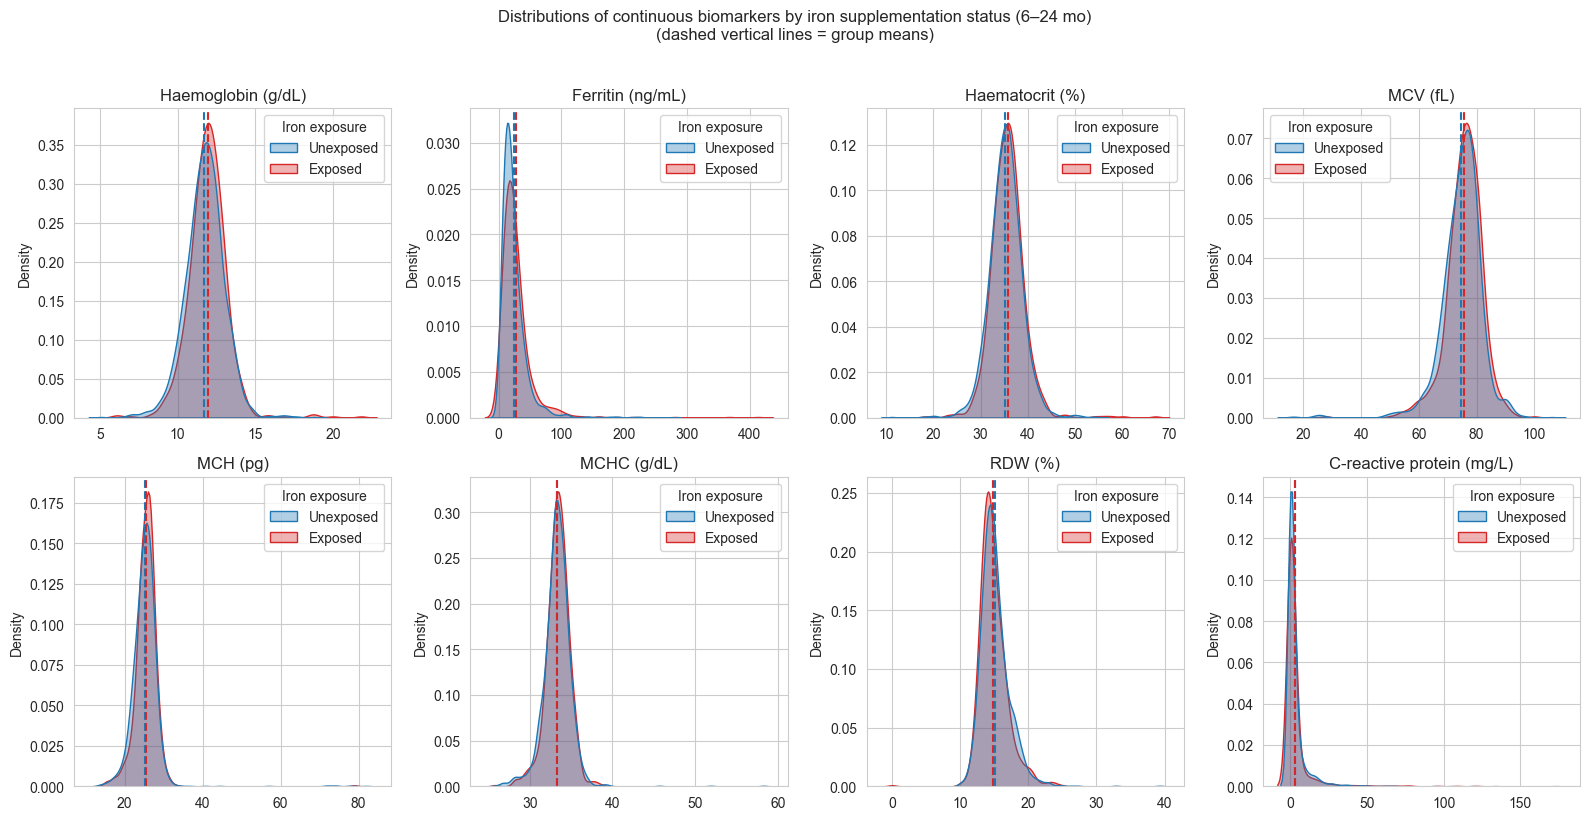

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, (var, label) in zip(axes.flatten(), continuous_biomarkers.items()):
    sub = df[[var, 'iron_any']].dropna()
    if len(sub) < 50:
        ax.set_visible(False)
        continue
    sns.kdeplot(
        data=sub, x=var, hue='iron_any',
        common_norm=False, fill=True, alpha=0.35,
        palette={0: 'C0', 1: 'C3'}, ax=ax,
    )
    mean_unexposed = sub.loc[sub['iron_any'] == 0, var].mean()
    mean_exposed = sub.loc[sub['iron_any'] == 1, var].mean()
    ax.axvline(mean_unexposed, color='C0', linestyle='--', linewidth=1.5)
    ax.axvline(mean_exposed, color='C3', linestyle='--', linewidth=1.5)
    ax.set_title(label)
    ax.set_xlabel('')
    legend = ax.get_legend()
    if legend is not None:
        legend.set_title('Iron exposure')
        for t, lab in zip(legend.texts, ['Unexposed', 'Exposed']):
            t.set_text(lab)
fig.suptitle(
    'Distributions of continuous biomarkers by iron supplementation status (6–24 mo)\n'
    '(dashed vertical lines = group means)', y=1.02,
)
fig.tight_layout()
plt.show()

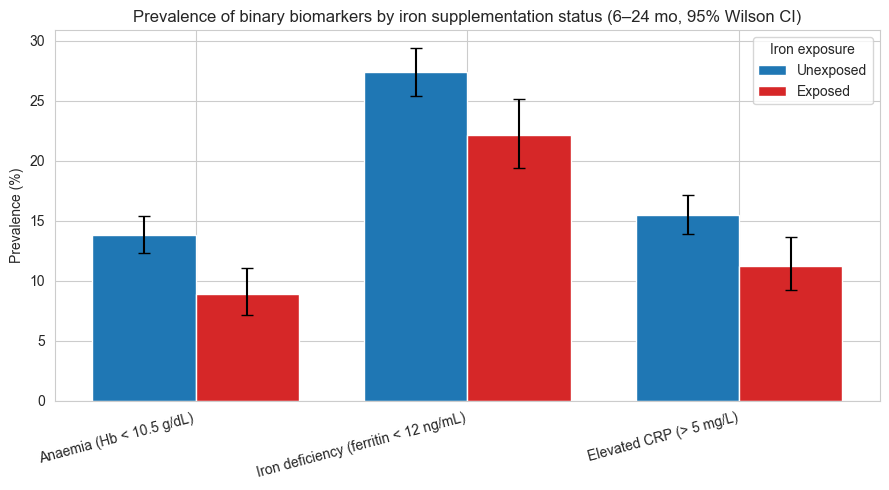

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))
labels = list(binary_biomarkers.values())
prev_unexposed = [binary_table.loc[binary_biomarkers[v], 'prev_unexposed'] * 100 for v in binary_biomarkers]
prev_exposed = [binary_table.loc[binary_biomarkers[v], 'prev_exposed'] * 100 for v in binary_biomarkers]
errs_unexposed = [
    [(binary_table.loc[binary_biomarkers[v], 'prev_unexposed'] - binary_table.loc[binary_biomarkers[v], 'prev_unexposed_lo']) * 100 for v in binary_biomarkers],
    [(binary_table.loc[binary_biomarkers[v], 'prev_unexposed_hi'] - binary_table.loc[binary_biomarkers[v], 'prev_unexposed']) * 100 for v in binary_biomarkers],
]
errs_exposed = [
    [(binary_table.loc[binary_biomarkers[v], 'prev_exposed'] - binary_table.loc[binary_biomarkers[v], 'prev_exposed_lo']) * 100 for v in binary_biomarkers],
    [(binary_table.loc[binary_biomarkers[v], 'prev_exposed_hi'] - binary_table.loc[binary_biomarkers[v], 'prev_exposed']) * 100 for v in binary_biomarkers],
]
x = np.arange(len(labels))
width = 0.38
ax.bar(x - width / 2, prev_unexposed, width, yerr=errs_unexposed, label='Unexposed', color='C0', capsize=4)
ax.bar(x + width / 2, prev_exposed, width, yerr=errs_exposed, label='Exposed', color='C3', capsize=4)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15, ha='right')
ax.set_ylabel('Prevalence (%)')
ax.set_title('Prevalence of binary biomarkers by iron supplementation status (6–24 mo, 95% Wilson CI)')
ax.legend(title='Iron exposure')
fig.tight_layout()
plt.show()

## 6. Forest plots — mean differences and risk differences with 95% CIs

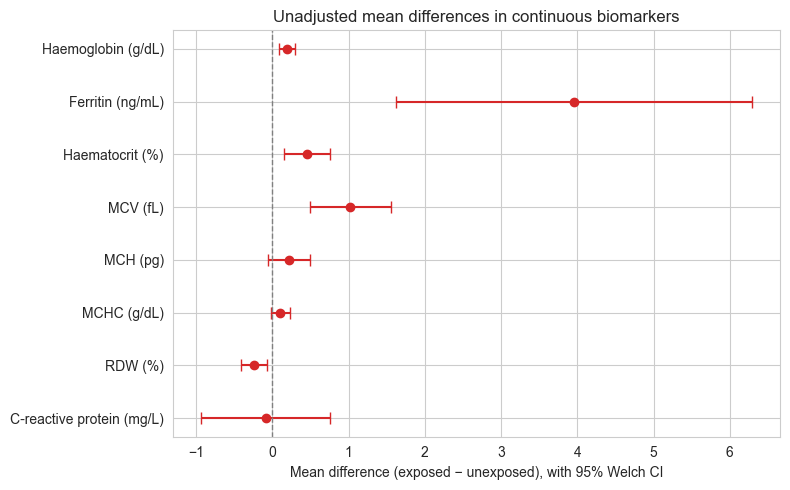

In [12]:
diff_df = pd.DataFrame({
    'Biomarker': continuous_table.index,
    'difference': continuous_table['mean_difference'].values,
    'lo': continuous_table['mean_difference_lo'].values,
    'hi': continuous_table['mean_difference_hi'].values,
})

fig, ax = plt.subplots(figsize=(8, 5))
y = np.arange(len(diff_df))
ax.errorbar(
    diff_df['difference'], y,
    xerr=[diff_df['difference'] - diff_df['lo'], diff_df['hi'] - diff_df['difference']],
    fmt='o', color='C3', ecolor='C3', capsize=4,
)
ax.axvline(0, color='gray', linestyle='--', linewidth=1)
ax.set_yticks(y)
ax.set_yticklabels(diff_df['Biomarker'])
ax.set_xlabel('Mean difference (exposed − unexposed), with 95% Welch CI')
ax.set_title('Unadjusted mean differences in continuous biomarkers')
ax.invert_yaxis()
fig.tight_layout()
plt.show()

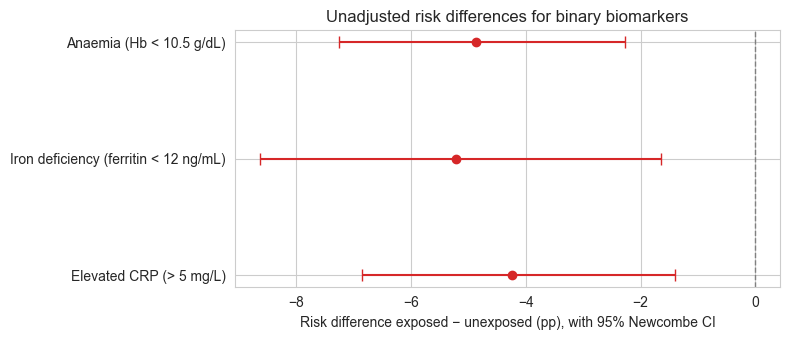

In [13]:
rd_df = pd.DataFrame({
    'Biomarker': binary_table.index,
    'difference': binary_table['risk_difference_pp'].values,
    'lo': binary_table['risk_difference_pp_lo'].values,
    'hi': binary_table['risk_difference_pp_hi'].values,
})

fig, ax = plt.subplots(figsize=(8, 3.5))
y = np.arange(len(rd_df))
ax.errorbar(
    rd_df['difference'], y,
    xerr=[rd_df['difference'] - rd_df['lo'], rd_df['hi'] - rd_df['difference']],
    fmt='o', color='C3', ecolor='C3', capsize=4,
)
ax.axvline(0, color='gray', linestyle='--', linewidth=1)
ax.set_yticks(y)
ax.set_yticklabels(rd_df['Biomarker'])
ax.set_xlabel('Risk difference exposed − unexposed (pp), with 95% Newcombe CI')
ax.set_title('Unadjusted risk differences for binary biomarkers')
ax.invert_yaxis()
fig.tight_layout()
plt.show()

## 7. Notes and caveats

- All comparisons are **unadjusted**. Adjusted estimates with outer-bootstrap inference will follow in a separate notebook.
- No causal claim is made from these comparisons. Differences observed here may reflect confounding (e.g., children with more healthcare contact are more likely both to receive PNSF iron and to differ in baseline biomarker profile).
- Sample sizes vary by biomarker because not every infant had every blood parameter measured under the ENANI protocol. Children with missing biomarker measurement are excluded from each comparison (NaN preserved); they are not classified as zero for the binary outcomes.
- Multiple-testing correction is not applied here. Pre-specified primary outcomes for the manuscript will receive Benjamini–Hochberg FDR correction in the adjusted-inference notebook.
- Hospitalisation outcomes are excluded by design from the manuscript and from this notebook (see `NARRATIVE.md` for justification).
- For right-skewed biomarkers (ferritin, CRP) the Welch t-test on the raw scale and the Mann–Whitney U on ranks can disagree. Both are reported.

## 8. Export all tables and figures to disk

All results are written to `02_descriptive_hematology_results/`, with tables as CSV and figures as PNG, plus a single `REPORT.md` that compiles everything. Re-running this notebook overwrites the contents of that folder.

In [14]:
OUTPUT_DIR = Path('./02_descriptive_hematology_results')
TABLES_DIR = OUTPUT_DIR / 'tables'
FIGURES_DIR = OUTPUT_DIR / 'figures'
OUTPUT_DIR.mkdir(exist_ok=True)
TABLES_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

availability.to_csv(TABLES_DIR / 'biomarker_availability.csv')
continuous_table.to_csv(TABLES_DIR / 'continuous_descriptives_full.csv')
continuous_compact.to_csv(TABLES_DIR / 'continuous_descriptives_compact.csv')
continuous_median_table.to_csv(TABLES_DIR / 'continuous_median_iqr.csv')
binary_table.to_csv(TABLES_DIR / 'binary_descriptives_full.csv')
binary_compact.to_csv(TABLES_DIR / 'binary_descriptives_compact.csv')
diff_df.to_csv(TABLES_DIR / 'mean_differences.csv', index=False)
rd_df.to_csv(TABLES_DIR / 'risk_differences.csv', index=False)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, (var, label) in zip(axes.flatten(), continuous_biomarkers.items()):
    sub = df[[var, 'iron_any']].dropna()
    if len(sub) < 50:
        ax.set_visible(False)
        continue
    sns.kdeplot(
        data=sub, x=var, hue='iron_any',
        common_norm=False, fill=True, alpha=0.35,
        palette={0: 'C0', 1: 'C3'}, ax=ax,
    )
    mean_unexposed = sub.loc[sub['iron_any'] == 0, var].mean()
    mean_exposed = sub.loc[sub['iron_any'] == 1, var].mean()
    ax.axvline(mean_unexposed, color='C0', linestyle='--', linewidth=1.5)
    ax.axvline(mean_exposed, color='C3', linestyle='--', linewidth=1.5)
    ax.set_title(label)
    ax.set_xlabel('')
    legend = ax.get_legend()
    if legend is not None:
        legend.set_title('Iron exposure')
        for t, lab in zip(legend.texts, ['Unexposed', 'Exposed']):
            t.set_text(lab)
fig.suptitle(
    'Distributions of continuous biomarkers by iron supplementation status (6–24 mo)\n'
    '(dashed vertical lines = group means)', y=1.02,
)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'kde_continuous_biomarkers.png', dpi=150, bbox_inches='tight')
plt.close(fig)

fig, ax = plt.subplots(figsize=(9, 5))
labels = list(binary_biomarkers.values())
prev_unexposed = [binary_table.loc[binary_biomarkers[v], 'prev_unexposed'] * 100 for v in binary_biomarkers]
prev_exposed = [binary_table.loc[binary_biomarkers[v], 'prev_exposed'] * 100 for v in binary_biomarkers]
errs_unexposed = [
    [(binary_table.loc[binary_biomarkers[v], 'prev_unexposed'] - binary_table.loc[binary_biomarkers[v], 'prev_unexposed_lo']) * 100 for v in binary_biomarkers],
    [(binary_table.loc[binary_biomarkers[v], 'prev_unexposed_hi'] - binary_table.loc[binary_biomarkers[v], 'prev_unexposed']) * 100 for v in binary_biomarkers],
]
errs_exposed = [
    [(binary_table.loc[binary_biomarkers[v], 'prev_exposed'] - binary_table.loc[binary_biomarkers[v], 'prev_exposed_lo']) * 100 for v in binary_biomarkers],
    [(binary_table.loc[binary_biomarkers[v], 'prev_exposed_hi'] - binary_table.loc[binary_biomarkers[v], 'prev_exposed']) * 100 for v in binary_biomarkers],
]
x = np.arange(len(labels))
width = 0.38
ax.bar(x - width / 2, prev_unexposed, width, yerr=errs_unexposed, label='Unexposed', color='C0', capsize=4)
ax.bar(x + width / 2, prev_exposed, width, yerr=errs_exposed, label='Exposed', color='C3', capsize=4)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15, ha='right')
ax.set_ylabel('Prevalence (%)')
ax.set_title('Prevalence of binary biomarkers by iron supplementation status (6–24 mo, 95% Wilson CI)')
ax.legend(title='Iron exposure')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'prevalence_binary_biomarkers.png', dpi=150, bbox_inches='tight')
plt.close(fig)

fig, ax = plt.subplots(figsize=(8, 5))
y = np.arange(len(diff_df))
ax.errorbar(
    diff_df['difference'], y,
    xerr=[diff_df['difference'] - diff_df['lo'], diff_df['hi'] - diff_df['difference']],
    fmt='o', color='C3', ecolor='C3', capsize=4,
)
ax.axvline(0, color='gray', linestyle='--', linewidth=1)
ax.set_yticks(y)
ax.set_yticklabels(diff_df['Biomarker'])
ax.set_xlabel('Mean difference (exposed − unexposed), with 95% Welch CI')
ax.set_title('Unadjusted mean differences in continuous biomarkers')
ax.invert_yaxis()
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'forest_mean_differences.png', dpi=150, bbox_inches='tight')
plt.close(fig)

fig, ax = plt.subplots(figsize=(8, 3.5))
y = np.arange(len(rd_df))
ax.errorbar(
    rd_df['difference'], y,
    xerr=[rd_df['difference'] - rd_df['lo'], rd_df['hi'] - rd_df['difference']],
    fmt='o', color='C3', ecolor='C3', capsize=4,
)
ax.axvline(0, color='gray', linestyle='--', linewidth=1)
ax.set_yticks(y)
ax.set_yticklabels(rd_df['Biomarker'])
ax.set_xlabel('Risk difference exposed − unexposed (pp), with 95% Newcombe CI')
ax.set_title('Unadjusted risk differences for binary biomarkers')
ax.invert_yaxis()
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'forest_risk_differences.png', dpi=150, bbox_inches='tight')
plt.close(fig)

report = []
report.append('# 01 — Descriptive comparison of haematological and inflammatory biomarkers by iron supplementation status\n')
report.append('**Sample:** Brazilian infants aged 6–24 months from ENANI-2019.\n')
report.append(f'**Analytic n:** {len(df):,} infants. **Iron-exposed:** {int(df["iron_any"].sum()):,} ({df["iron_any"].mean() * 100:.1f}%).\n')
report.append('**Comparisons reported below are unadjusted.** Adjusted estimates with outer-bootstrap inference will follow in a separate notebook. No causal claim is made from this report.\n')
report.append('---\n')
report.append('## Biomarker availability\n')
report.append(availability.to_markdown() + '\n')
report.append('## Continuous biomarkers — group means and unadjusted mean differences (95% CI)\n')
report.append(continuous_compact.to_markdown() + '\n')
report.append('## Continuous biomarkers — medians and IQRs\n')
report.append(continuous_median_table.to_markdown() + '\n')
report.append('## Binary biomarkers — prevalences and unadjusted risk differences (95% CI)\n')
report.append(binary_compact.to_markdown() + '\n')
report.append('## Distribution plots\n')
report.append('Dashed vertical lines mark group means.\n')
report.append('![KDE distributions](figures/kde_continuous_biomarkers.png)\n')
report.append('## Prevalence of binary biomarkers (95% Wilson CI on each bar)\n')
report.append('![Binary prevalences](figures/prevalence_binary_biomarkers.png)\n')
report.append('## Forest plot — mean differences (continuous biomarkers, 95% Welch CI)\n')
report.append('![Forest plot of mean differences](figures/forest_mean_differences.png)\n')
report.append('## Forest plot — risk differences (binary biomarkers, 95% Newcombe CI)\n')
report.append('![Forest plot of risk differences](figures/forest_risk_differences.png)\n')
report.append('---\n')
report.append('## Notes\n')
report.append('- Estimates are unadjusted; confounding is not addressed at this stage.\n')
report.append('- Children with missing biomarker measurement are excluded (NaN preserved); they are not classified as zero.\n')
report.append('- No multiple-testing correction is applied at this stage.\n')
report.append('- Sample sizes vary by biomarker because not every infant had every blood parameter measured under the ENANI protocol.\n')
report.append('- Hospitalisation outcomes are excluded from the manuscript by design (see `NARRATIVE.md`).\n')
report.append('- For right-skewed biomarkers (ferritin, CRP) Welch t-test on the raw scale and Mann–Whitney U on ranks may disagree; both are reported.\n')
(OUTPUT_DIR / 'REPORT.md').write_text('\n'.join(report))

print(f'Outputs written to: {OUTPUT_DIR.resolve()}')
for path in sorted(OUTPUT_DIR.rglob('*')):
    if path.is_file():
        size_kb = path.stat().st_size / 1024
        print(f'  {path.relative_to(OUTPUT_DIR)}  ({size_kb:.1f} KB)')

Outputs written to: /Users/marcelocarvalhoesilva/project/IronBrazil/Analysis/02_descriptive_hematology_results
  REPORT.md  (6.5 KB)
  figures/forest_mean_differences.png  (50.1 KB)
  figures/forest_risk_differences.png  (36.3 KB)
  figures/kde_continuous_biomarkers.png  (265.8 KB)
  figures/prevalence_binary_biomarkers.png  (57.5 KB)
  tables/binary_descriptives_compact.csv  (0.5 KB)
  tables/binary_descriptives_full.csv  (1.0 KB)
  tables/biomarker_availability.csv  (0.4 KB)
  tables/continuous_descriptives_compact.csv  (0.9 KB)
  tables/continuous_descriptives_full.csv  (2.7 KB)
  tables/continuous_median_iqr.csv  (0.6 KB)
  tables/mean_differences.csv  (0.6 KB)
  tables/risk_differences.csv  (0.3 KB)
